In [1]:
import sklearn
import sklearn.cluster
import sklearn.impute
import geopandas
import pandas
import shapely
import matplotlib.pyplot as plt

(20.0, 50.0)

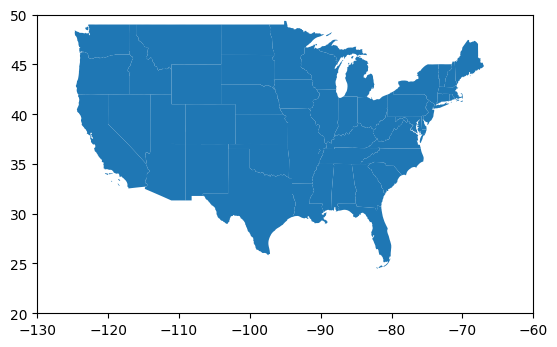

In [4]:
map = geopandas.read_file("cb_2024_us_state_20m.zip")
ax = map.plot()
ax.set_xlim(-130, -60)
ax.set_ylim(20, 50)

In [7]:
data = pandas.read_csv("SASUMMARY__ALL_AREAS_1998_2024.csv")
name = data[data["LineCode"] == 1.0]["GeoName"].reset_index(drop = True)
dpi = data[data["LineCode"] == 11.0]["2023"].reset_index(drop = True)
pce = data[data["LineCode"] == 12.0]["2023"].reset_index(drop = True)
rpp = data[data["LineCode"] == 13.0]["2023"].reset_index(drop = True)
sub = pandas.concat([name, dpi, pce, rpp], axis = 1)
sub.columns = ["NAME", "DPI", "PCE", "RPP"]
sub

,NAME,DPI,PCE,RPP
0,United States,60947,56202,100.000
1,Alabama,48857,44529,89.970
2,Alaska,65665,62900,101.715
3,Arizona,55979,53921,101.105
4,Arkansas,52253,44254,86.508
5,California,68728,64835,112.581
6,Colorado,69897,63781,101.382
7,Connecticut,75574,65128,103.689
8,Delaware,58530,57672,99.253
9,District of Columbia,88450,92037,110.804


In [8]:
combined = map.merge(sub, how = "left", on = "NAME")[["NAME", "geometry", "DPI", "PCE", "RPP"]]
combined.head(5)

,NAME,geometry,DPI,PCE,RPP
0,Texas,"POLYGON ((-106.62345 31.91403, -106.63011 31.9...",59707,52299,97.175
1,California,"MULTIPOLYGON (((-118.59397 33.46720, -118.4847...",68728,64835,112.581
2,Kentucky,"POLYGON ((-89.54443 36.57451, -89.47935 36.566...",49477,47272,90.468
3,Georgia,"POLYGON ((-85.60516 34.98468, -85.47434 34.983...",52712,50282,96.699
4,Wisconsin,"MULTIPOLYGON (((-86.93428 45.42115, -86.83575 ...",57640,52593,93.097


In [10]:
features = combined[["DPI", "PCE", "RPP"]]
impute = sklearn.impute.SimpleImputer(strategy = "mean")
impute.fit(features)
full = impute.transform(features)
scale = sklearn.preprocessing.StandardScaler()
scale.fit(full)
x = scale.transform(full)
x[0:10, :]

array([[-0.05467925, -0.34583404,  0.04825945],
       [ 1.06228804,  1.19531586,  2.24193855],
       [-1.32134319, -0.96384302, -0.90675844],
       [-0.92079013, -0.59379985, -0.01951876],
       [-0.31061223, -0.30969029, -0.53241193],
       [-0.22232959,  0.03687174,  1.12274358],
       [-0.53497147, -0.3706675 , -0.72250421],
       [ 0.52219145,  0.08162114,  0.55716567],
       [-0.41907729, -0.71132851, -0.61528362],
       [-0.82829766, -0.82209558, -1.209055  ]])

(20.0, 50.0)

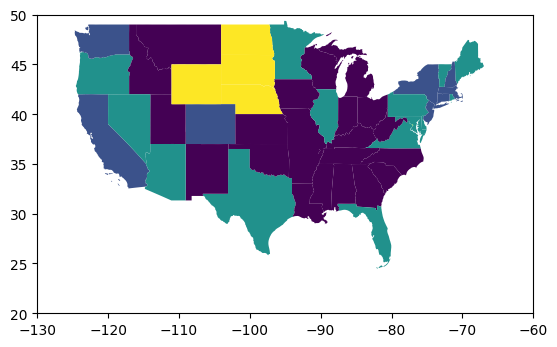

In [14]:
cluster = sklearn.cluster.AgglomerativeClustering(n_clusters = 5)
cluster.fit(x)
ax = map.plot(cluster.labels_)
ax.set_xlim(-130, -60)
ax.set_ylim(20, 50)

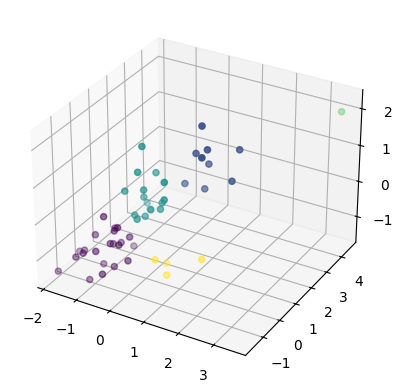

In [12]:
fig = plt.figure()
ax = fig.add_subplot(projection = "3d")
ax.scatter(x[:, 0], x[:, 1], x[:, 2], c = cluster.labels_)

In [ ]:
cluster = sklearn.cluster.KMeans(n_clusters = 5, n_init = 1)
cluster.fit(x)
ax = map.plot(cluster.labels_)
ax.set_xlim(-130, -60)
ax.set_ylim(20, 50)

In [ ]:
cluster.fit(x)
ax = map.plot(cluster.labels_)
ax.set_xlim(-130, -60)
ax.set_ylim(20, 50)

In [ ]:
td = []
n = range(1, len(x))
for k in n:
    cluster = sklearn.cluster.KMeans(n_clusters = k, n_init = 1)
    cluster.fit(x)
    td.append(cluster.inertia_)
plt.scatter(n, td)